In [18]:
# Libraries
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('default')
%matplotlib inline
from mplfinance.original_flavor import candlestick_ohlc
import matplotlib.dates as mpdates

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.layers import Input, LSTM, Dense, concatenate
from tensorflow.keras.metrics import RootMeanSquaredError, MeanAbsoluteError, MeanAbsolutePercentageError
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, BatchNormalization, Bidirectional, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt


In [2]:
# Load dataset
df_compiled = pd.read_csv('for_LSTM_hybrid.csv', parse_dates=['Date'], index_col='Date')
df_compiled.loc['2019-01-01':'2025-01-01'].dropna()
df_compiled.columns.tolist()

['Close',
 'High',
 'Low',
 'Open',
 'Volume',
 'headline',
 'Polarity',
 'Subjectivity',
 'Sentiment',
 'VADER_Score',
 'VADER_Sentiment',
 'MACD',
 'MACD_signal',
 'MACD_hist',
 'RSI_14',
 'SMA_13',
 'SMA_49',
 'EMA_13',
 'EMA_49']

In [3]:
df_compiled

,Close,High,Low,Open,Volume,headline,Polarity,Subjectivity,Sentiment,VADER_Score,VADER_Sentiment,MACD,MACD_signal,MACD_hist,RSI_14,SMA_13,SMA_49,EMA_13,EMA_49
Date,,,,,,,,,,,,,,,,,,,
2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,NaN,0.00,0.0,Neutral,0.0000,Neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,NaN,0.00,0.0,Neutral,0.0000,Neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,NaN,0.00,0.0,Neutral,0.0000,Neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,NaN,0.00,0.0,Neutral,0.0000,Neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,NaN,0.00,0.0,Neutral,0.0000,Neutral,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400,NaN,0.00,0.0,Neutral,0.0000,Neutral,-3.254057,-3.169868,-0.084189,48.687258,1603.240751,1610.690407,1601.390233,1610.692668
2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600,Skin Tightening and Lifting Treatment - MH Clinic,0.00,0.0,Neutral,0.0000,Neutral,-2.013781,-2.938650,0.924869,55.912476,1603.275362,1610.304080,1603.148764,1610.812959
2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200,"Military Connections, Investment Efficiency an...",-0.05,0.1,Neutral,0.0258,Neutral,0.132808,-2.324359,2.457166,63.396201,1604.560744,1610.032653,1606.718943,1611.506042


In [4]:
# Separate Features
tech_feats = [ 'MACD',
 'MACD_signal',
 'MACD_hist',
 'RSI_14',
 'SMA_13',
 'SMA_49',
 'EMA_13',
 'EMA_49']

senti_feats = ['Polarity',
 'Subjectivity',
 'Sentiment',
 'VADER_Score',
 'VADER_Sentiment']



In [5]:
df_compiled['VADER_Sentiment'] = df_compiled['VADER_Sentiment'].replace({
    'Neutral': 0.0,
    'Positive': 1.0,
    'Negative': -1.0
})


C:\Users\badar\AppData\Local\Temp\ipykernel_19816\3169199099.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_compiled['VADER_Sentiment'] = df_compiled['VADER_Sentiment'].replace({


In [6]:
df_compiled['Sentiment'] = df_compiled['Sentiment'].replace({
    'Neutral': 0.0,
    'Positive': 1.0,
    'Negative': -1.0
})


C:\Users\badar\AppData\Local\Temp\ipykernel_19816\2599741197.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_compiled['Sentiment'] = df_compiled['Sentiment'].replace({


In [7]:
df_compiled

,Close,High,Low,Open,Volume,headline,Polarity,Subjectivity,Sentiment,VADER_Score,VADER_Sentiment,MACD,MACD_signal,MACD_hist,RSI_14,SMA_13,SMA_49,EMA_13,EMA_49
Date,,,,,,,,,,,,,,,,,,,
2019-01-02,1668.109985,1694.099976,1666.069946,1693.510010,47769800,NaN,0.00,0.0,0.0,0.0000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,1675.829956,1680.780029,1666.219971,1675.160034,69484500,NaN,0.00,0.0,0.0,0.0000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,1669.780029,1676.550049,1668.150024,1672.579956,64869000,NaN,0.00,0.0,0.0,0.0000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-07,1679.170044,1687.130005,1673.030029,1674.920044,144668500,NaN,0.00,0.0,0.0,0.0000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-08,1672.760010,1686.369995,1670.670044,1685.719971,176071900,NaN,0.00,0.0,0.0,0.0000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,1602.989990,1603.890015,1596.640015,1596.640015,95048400,NaN,0.00,0.0,0.0,0.0000,0.0,-3.254057,-3.169868,-0.084189,48.687258,1603.240751,1610.690407,1601.390233,1610.692668
2024-12-26,1613.699951,1615.280029,1602.790039,1603.579956,120934600,Skin Tightening and Lifting Treatment - MH Clinic,0.00,0.0,0.0,0.0000,0.0,-2.013781,-2.938650,0.924869,55.912476,1603.275362,1610.304080,1603.148764,1610.812959
2024-12-27,1628.140015,1632.630005,1616.689941,1617.560059,130614200,"Military Connections, Investment Efficiency an...",-0.05,0.1,0.0,0.0258,0.0,0.132808,-2.324359,2.457166,63.396201,1604.560744,1610.032653,1606.718943,1611.506042


In [8]:
df_compiled['VADER_Sentiment'] = pd.to_numeric(df_compiled['VADER_Sentiment'], errors='coerce')
df_compiled['Sentiment'] = pd.to_numeric(df_compiled['Sentiment'], errors='coerce')


In [9]:
# Re-scaler 
scaler_tech = MinMaxScaler()
scaler_senti = MinMaxScaler()
scaler_y = MinMaxScaler()

df_tech = pd.DataFrame(scaler_tech.fit_transform(df_compiled[tech_feats]), index=df_compiled.index, columns=tech_feats)
df_senti = pd.DataFrame(scaler_senti.fit_transform(df_compiled[senti_feats]), index=df_compiled.index, columns=senti_feats)
df_y = pd.DataFrame(scaler_y.fit_transform(df_compiled[['Close']]), index=df_compiled.index, columns=['Close_norm'])

df_y['Close_norm'] = scaler_y.fit_transform(df_compiled[['Close']])



In [10]:
# Create Time-Series Sequences
def create_sequences(df_x, df_y, seq_len=60):
    X, y = [],[]
    for i in range(seq_len, len(df_x)):
        X.append(df_x.iloc[i-seq_len:i].values)
        y.append(df_y.iloc[i].values)
    return np.array(X), np.array(y)

seq_len = 60

X_tech, y = create_sequences(df_tech, df_y, seq_len)
X_senti, _ = create_sequences(df_senti, df_y, seq_len)
y = y.squeeze()

In [11]:
# Split Into Train, Validation, and Test Sets
n = len(X_tech)
i1, i2 = int(n*0.7), int(n*0.9)

Xtech_train, Xtech_val, Xtech_test = X_tech[:i1], X_tech[i1:i2], X_tech[i2:]
Xsenti_train, Xsenti_val, Xsenti_test = X_senti[:i1], X_senti[i1:i2], X_senti[i2:]
y_train, y_val, y_test = y[:i1], y[i1:i2], y[i2:]


Bidirectional LSTM helps capture past and future patterns 

Stacked LSTM layers deepen sequence learning — proven in time-series forecasting 

Dropout & recurrent_dropout combat overfitting per best practices .

BatchNormalization stabilizes training and helps convergence .

Dense layers with Dropout add more modeling power while avoiding over-parameterization.

In [19]:
# Build the Hybrid Two-Stream LSTM Model
tech_in = Input(shape=(seq_len, len(tech_feats)), name='tech_input')
x1 = Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2))(tech_in)
x1 = BatchNormalization()(x1)
x1 = LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(x1)

senti_in = Input(shape=(seq_len, len(senti_feats)), name='senti_input')
x2 = LSTM(64, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)(senti_in)

# Merge
merged = concatenate([x1, x2])
x = Dense(64, activation='relu')(merged)
x = Dropout(0.3)(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, name='pred_close')(x)

model = Model([tech_in, senti_in], output)

# Compile with regression metrics
model.compile(optimizer='adam', loss='mse', metrics=[
        RootMeanSquaredError(name='rmse'),
        MeanAbsoluteError(name='mae'),
        MeanAbsolutePercentageError(name='mape')
    ]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tech_input          │ (None, 60, 8)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 60, 256)   │    140,288 │ tech_input[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 60, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ senti_input         │ (None, 60, 5)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_3 (LSTM)       │ (None, 64)        │     82,176 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_4 (LSTM)       │ (None, 64)        │     17,920 │ senti_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 128)       │          0 │ lstm_3[0][0],     │
│ (Concatenate)       │                   │            │ lstm_4[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pred_close (Dense)  │ (None, 1)         │         33 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 251,777 (983.50 KB)

 Trainable params: 251,265 (981.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [20]:
# Train with Validation
history = model.fit(
    [Xtech_train, Xsenti_train], y_train,
    validation_data=([Xtech_val, Xsenti_val], y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 23s 251ms/step - loss: 0.4000 - mae: 0.6151 - mape: 6737.7568 - rmse: 0.6324 - val_loss: 0.2381 - val_mae: 0.4708 - val_mape: 93.4521 - val_rmse: 0.4879
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - loss: 0.3653 - mae: 0.5851 - mape: 37648.5938 - rmse: 0.6043 - val_loss: 0.2105 - val_mae: 0.4406 - val_mape: 87.0409 - val_rmse: 0.4588
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - loss: 0.3308 - mae: 0.5532 - mape: 54760.5469 - rmse: 0.5751 - val_loss: 0.1854 - val_mae: 0.4111 - val_mape: 80.7965 - val_rmse: 0.4306
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - loss: 0.2955 - mae: 0.5232 - mape: 165410.9844 - rmse: 0.5436 - val_loss: 0.1627 - val_mae: 0.3825 - val_mape: 74.7291 - val_rmse: 0.4033
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - loss: 0.2635 - mae: 0.4925 - mape: 9342.6670 - rmse: 0.5133 - val_loss: 0.1422 - val_mae: 0.3547 - val_mape: 68.8412 - val_rmse: 0.3771
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 208m

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 482ms/step


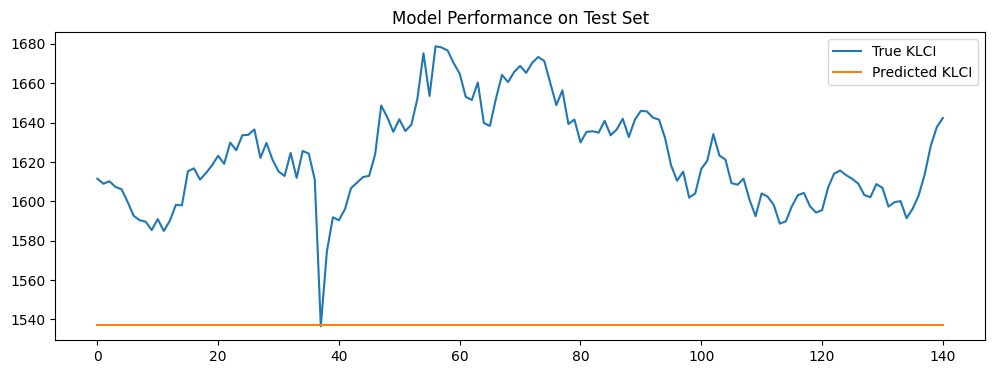

In [21]:
# Evaluate & Rescale Real Values
pred_norm = model.predict([Xtech_test, Xsenti_test]).flatten()
y_true = scaler_y.inverse_transform(y_test.reshape(-1,1)).flatten()
y_pred = scaler_y.inverse_transform(pred_norm.reshape(-1,1)).flatten()

plt.figure(figsize=(12,4))
plt.plot(y_true, label='True KLCI')
plt.plot(y_pred, label='Predicted KLCI')
plt.title('Model Performance on Test Set')
plt.legend()
plt.show()


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'MAPE: {mape:.2f}%')

MSE: 7991.96
RMSE: 89.40
MAE: 85.76
MAPE: 5.26%


In [15]:
# Simulate Two-Year Forecast
last_tech = Xtech_test[-1:]
last_sent = Xsenti_test[-1:]
future = []

for _ in range(504):  # approx 2 trading years
    pred = model.predict([last_tech, last_sent])[0,0]
    future.append(pred)

    # shift and append new data (you can loop forward your close and sentiment)
    last_tech = np.roll(last_tech, -1, axis=1)
    last_tech[0,-1,:] = np.concatenate([last_tech[0,-1,:len(tech_feats)-1], last_tech[0,-1,-1:]])  # placeholder
    last_sent = np.roll(last_sent, -1, axis=1)
    last_sent[0,-1,:] = last_sent[0,-1,:]  # placeholder


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━

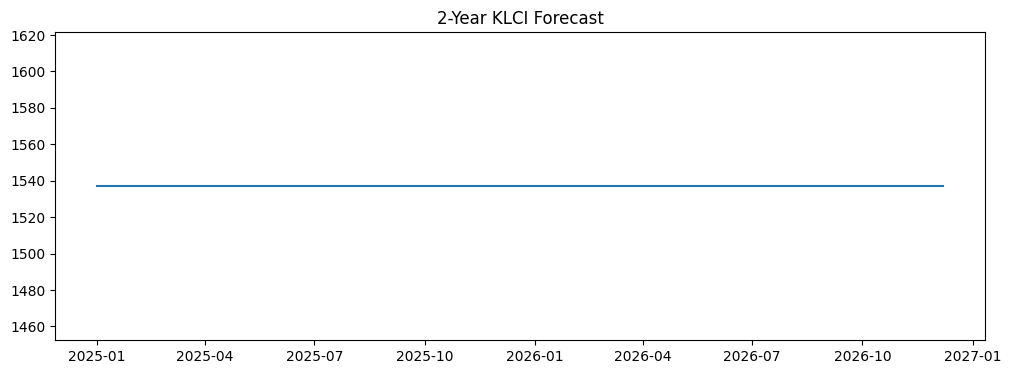

In [16]:
# Visualize Forecast Horizon
future_real = scaler_y.inverse_transform(np.array(future).reshape(-1,1)).flatten()

plt.figure(figsize=(12,4))
plt.plot(pd.date_range(start=df_y.index[-1], periods=len(future)+1, freq='B')[1:], future_real)
plt.title('2-Year KLCI Forecast')
plt.show()
